# Attribute Types, Interval vs Ratio
### CIS*4020 · a short, hands-on Python notebook companion to data attributes

1. **Attributes** — simple examples of the four types
2. **What each type lets you do** — which operations and statistics make sense
3. **Interval vs ratio** — the true-zero distinction, and why it matters
4. **Transformations & standardization** — `a·x + b` vs `a·x`, and what happens to your
   statistics when you standardize

Self-contained: only `numpy`, `pandas`, `matplotlib`.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 30)

## 1. Attributes: a few simple examples

A tiny table of people. Each column is an *attribute* of a person (an *object*).

In [2]:
people = pd.DataFrame({
    "person_id":      [101, 102, 103, 104, 105],
    "eye_colour":      ["brown","blue","brown","green","blue"],
    "tshirt_size":    ["M","S","L","M","L"],
    "birth_year":     [1998, 1990, 2003, 1985, 2000],
    "temp_pref_C":    [21, 19, 23, 20, 22],
    "age":            [27, 35, 15, 40, 25],
    "height_cm":      [170, 182, 155, 168, 175],
    "monthly_income": [3200, 5400, 0, 7100, 2800],
    "num_pets":       [0, 2, 1, 0, 3],
})
people

,person_id,eye_colour,tshirt_size,birth_year,temp_pref_C,age,height_cm,monthly_income,num_pets
0,101,brown,M,1998,21,27,170,3200,0
1,102,blue,S,1990,19,35,182,5400,2
2,103,brown,L,2003,23,15,155,0,1
3,104,green,M,1985,20,40,168,7100,0
4,105,blue,L,2000,22,25,175,2800,3


**Watch out:** the pandas *dtype* is not the *attribute type*. `person_id` and `age` are both
stored as integers, but one is nominal (arithmetic is meaningless) and the other is ratio.

In [3]:
people.dtypes

,0
person_id,int64
eye_colour,object
tshirt_size,object
birth_year,int64
temp_pref_C,int64
age,int64
height_cm,int64
monthly_income,int64
num_pets,int64


In [4]:
ref = pd.DataFrame([
 ("person_id","Nominal","identifier; only == / != makes sense","mode, frequency"),
 ("eye_colour","Nominal","unordered categories","mode, frequency"),
 ("tshirt_size","Ordinal","ordered S < M < L; spacing unknown","median, min/max"),
 ("birth_year","Interval","year; the zero point is arbitrary","differences, mean"),
 ("temp_pref_C","Interval","Celsius; arbitrary zero","differences, mean"),
 ("age","Ratio","true zero (0 = birth)","ratios, mean, CV"),
 ("height_cm","Ratio","true zero","ratios, mean, CV"),
 ("monthly_income","Ratio","true zero (0 = none)","ratios, mean"),
 ("num_pets","Ratio","count; true zero","ratios, mean"),
], columns=["column","attribute_type","why","example statistics"])
ref

,column,attribute_type,why,example statistics
0,person_id,Nominal,identifier; only == / != makes sense,"mode, frequency"
1,eye_colour,Nominal,unordered categories,"mode, frequency"
2,tshirt_size,Ordinal,ordered S < M < L; spacing unknown,"median, min/max"
3,birth_year,Interval,year; the zero point is arbitrary,"differences, mean"
4,temp_pref_C,Interval,Celsius; arbitrary zero,"differences, mean"
5,age,Ratio,true zero (0 = birth),"ratios, mean, CV"
6,height_cm,Ratio,true zero,"ratios, mean, CV"
7,monthly_income,Ratio,true zero (0 = none),"ratios, mean"
8,num_pets,Ratio,count; true zero,"ratios, mean"


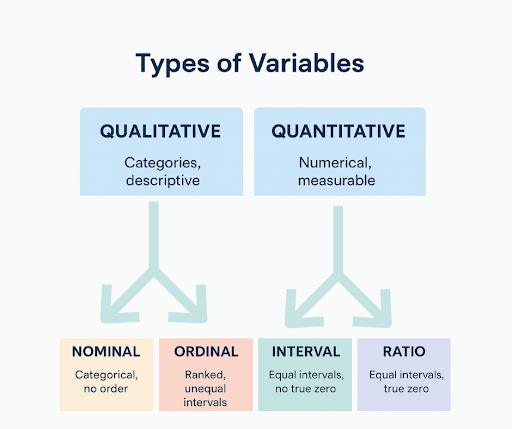

## 2. What each type lets you do

The attribute type decides which operations and statistics are meaningful.

In [5]:
# NOMINAL: only equality; use frequency and mode. A "mean" is meaningless.
print("eye_colour frequencies:"); print(people["eye_colour"].value_counts().to_string())
print("mode:", people["eye_colour"].mode()[0])
codes, _ = pd.factorize(people["eye_colour"])
print(codes)
print("\n'mean of eye-colour codes' =", codes.mean(), " <- Doesn't mean anything (labels aren't numbers)")

eye_colour frequencies:
eye_colour
brown    2
blue     2
green    1
mode: blue
[0 1 0 2 1]

'mean of eye-colour codes' = 0.8  <- Doesn't mean anything (labels aren't numbers)


In [6]:
# ORDINAL: order is meaningful, spacing is NOT.
size = pd.Categorical(people["tshirt_size"], categories=["S","M","L"], ordered=True)
print("can we order the elements? L > M is", size.categories.get_loc("L") > size.categories.get_loc("M"))
print("median size:", size.categories[int(np.median(size.codes))])
print("but 'L - M' is undefined: we don't know if the gaps are equal (S->M may differ from M->L)")
#print(size.codes)

can we order the elements? L > M is True
median size: M
but 'L - M' is undefined: we don't know if the gaps are equal (S->M may differ from M->L)


In [7]:
# INTERVAL: differences are meaningful; ratios are NOT.
by = people["birth_year"]
print("age gap between two people (a DIFFERENCE) is meaningful:", int(by.max() - by.min()), "years")
print("but 'born in 2003 is 1.009x born in 1985' doesn't make any sense -> \033[1mratios don't apply to interval data\033[0m")

age gap between two people (a DIFFERENCE) is meaningful: 18 years
but 'born in 2003 is 1.009x born in 1985' doesn't make any sense -> ratios don't apply to interval data


In [8]:
# RATIO: differences AND ratios are meaningful.
print("age: 40 is exactly", 40/20, "x as old as 20  -> \033[1mratios apply\033[0m")
print("income % change 2800 -> 5400:", round((5400-2800)/2800*100, 1), "%  -> \033[1mneeds a true zero\033[0m")

age: 40 is exactly 2.0 x as old as 20  -> ratios apply
income % change 2800 -> 5400: 92.9 %  -> needs a true zero


# How to Correctly Identify Your Variable?

When classifying your data, these are some essential questions to keep in mind:

### Does your data represent categories?
* **Yes** $\rightarrow$ Nominal or Ordinal
* **No** $\rightarrow$ Interval or Ratio

### Do categories have a meaningful order?
* **Yes** $\rightarrow$ Ordinal
* **No** $\rightarrow$ Nominal

### Is zero meaningful in your numeric scale?
* **Yes** $\rightarrow$ Ratio
* **No** $\rightarrow$ Interval

---

## Nominal vs Ordinal

* **Nominal:** Categories without order (e.g., eye colour)
* **Ordinal:** Categories with meaningful order (e.g., t-shirt size)

---

## Interval vs Ratio

* **Interval:** No true zero (e.g., Temperature °C)
* **Ratio:** Has true zero (e.g., Weight)

## 3. Interval vs ratio: it's all about the zero

The whole difference is whether **zero means "none of the thing."**
- **Ratio** has a *true* zero (0 kg = no mass) -> "twice as much" is meaningful.
- **Interval** has an *arbitrary* zero (0 C is just a mark) -> "twice as much" is not  meaningful.

The quickest test: **change the units and see if the ratio survives.**

In [9]:
def ratio_under_units(label, pair, conversions):
    print(f"{label}: {pair[0]} vs {pair[1]}")
    for unit, f in conversions.items():
        a, b = f(pair[0]), f(pair[1])
        print(f"    in {unit:>10}: {a:8.2f} vs {b:8.2f}   ->   ratio {b/a:.2f}")
    print()

ratio_under_units("Temperature (INTERVAL)", (10, 20), {
    "Celsius":    lambda c: c,
    "Fahrenheit": lambda c: c*9/5 + 32,
    "Kelvin":     lambda c: c + 273.15,     # true-zero scale -> the REAL ratio
})
ratio_under_units("Length (RATIO)", (5, 10), {
    "metres": lambda m: m,
    "feet":   lambda m: m*3.28084,
    "inches": lambda m: m*39.3701,
})
print("Temperature's '2x' changes with the unit -> it was never a real ratio.")
print("Length stays 2x in every unit -> the ratio is real (true zero).")

Temperature (INTERVAL): 10 vs 20
    in    Celsius:    10.00 vs    20.00   ->   ratio 2.00
    in Fahrenheit:    50.00 vs    68.00   ->   ratio 1.36
    in     Kelvin:   283.15 vs   293.15   ->   ratio 1.04

Length (RATIO): 5 vs 10
    in     metres:     5.00 vs    10.00   ->   ratio 2.00
    in       feet:    16.40 vs    32.81   ->   ratio 2.00
    in     inches:   196.85 vs   393.70   ->   ratio 2.00

Temperature's '2x' changes with the unit -> it was never a real ratio.
Length stays 2x in every unit -> the ratio is real (true zero).


## 4. Transformations: `a·x + b` (interval) vs `a·x` (ratio)

Each scale only tolerates transformations that **preserve its meaning**:
- **Interval** allows `new = a·old + b` (slide the arbitrary origin with `b`, rescale with `a`).
- **Ratio** allows `new = a·old` only (`b` must be 0, or you'd move the true zero).

Let's see exactly what each preserves.

In [10]:
def check_transform(x, a, b, name):
    y = a*x + b
    order_ok = np.array_equal(np.argsort(x), np.argsort(y))
    # ratio of two values (does 2nd/1st stay the same?)
    rx, ry = x[1]/x[0], y[1]/y[0]
    ratio_ok = np.isclose(rx, ry)
    print(f"{name}:  new = {a}*x + {b}")
    print(f"    order preserved? {order_ok}")
    print(f"    value ratio x[1]/x[0]: {rx:.3f} -> {ry:.3f}   preserved? {ratio_ok}")
    print()

temps = np.array([10., 20., 30.])
check_transform(temps, 1.8, 32, "INTERVAL (C->F)")     # b != 0
lengths = np.array([5., 10., 20.])
check_transform(lengths, 3.281, 0, "RATIO (m->ft)")   # b == 0

INTERVAL (C->F):  new = 1.8*x + 32
    order preserved? True
    value ratio x[1]/x[0]: 2.000 -> 1.360   preserved? False

RATIO (m->ft):  new = 3.281*x + 0
    order preserved? True
    value ratio x[1]/x[0]: 2.000 -> 2.000   preserved? True



Both keep the **order**. Only the ratio transform (`b = 0`) keeps the **value ratios** —
the affine transform's `+b` breaks them. That single fact drives everything below.

## 5. Why it matters for statistics

A statistic is **meaningful** only if the conclusion it supports survives the scale's allowed transforms.

In [11]:
x = np.array([2, 4, 6, 8])
a, b = 3.0, 5.0
print("mean(a*x + b)      =", (a*x + b).mean())
print("a*mean(x) + b      =", a*x.mean() + b, " -> equal, so the MEAN behaves well under the linear transformation")
print("=> comparing means is safe for INTERVAL data\n")

def cv(v): return v.std(ddof=0) / v.mean()
print("Coefficient of variation (std/mean):")
print(f"    x           CV = {cv(x):.4f}")
print(f"    a*x (scale) CV = {cv(a*x):.4f}   <- unchanged (ratio transform)")
print(f"    x + b (shift) CV = {cv(x + b):.4f}   <- CHANGED (affine shift)")
print("=> CV, value ratios, % change, geometric mean need a RATIO scale (true zero)")

mean(a*x + b)      = 20.0
a*mean(x) + b      = 20.0  -> equal, so the MEAN behaves well under the linear transformation
=> comparing means is safe for INTERVAL data

Coefficient of variation (std/mean):
    x           CV = 0.4472
    a*x (scale) CV = 0.4472   <- unchanged (ratio transform)
    x + b (shift) CV = 0.2236   <- CHANGED (affine shift)
=> CV, value ratios, % change, geometric mean need a RATIO scale (true zero)


## 6. Why it matters for data standardization

Standardization is just a transformation — and most standardizers are **affine (`a·x + b`)**, so they
**move a ratio variable's true zero**. Take a ratio variable (say, hourly bike rentals) and compare
common transforms.

In [12]:
x = np.array([10., 20., 40.])          # a ratio variable: 0 would mean "none"
transforms = {
    "original":          x,
    "unit x2  (a*x)":    2*x,
    "max-abs  (a*x)":    x/np.abs(x).max(),
    "min-max  (a*x+b)":  (x - x.min())/(x.max() - x.min()),
    "z-score  (a*x+b)":  (x - x.mean())/x.std(ddof=0),
    "log      (non-affine)": np.log(x),
}
rows = []
for name, v in transforms.items():
    mean = v.mean()
    ratio = v[2]/v[0] if v[0] != 0 else np.nan          # was 4.0 (40/10); is it still?
    cvv = v.std(ddof=0)/mean if not np.isclose(mean,0) else np.inf
    rows.append((name, np.round(v,3), round(ratio,3), round(cvv,3) if np.isfinite(cvv) else "undefined"))
pd.DataFrame(rows, columns=["transform","values","ratio v3/v1","CV"])

,transform,values,ratio v3/v1,CV
0,original,"[10.0, 20.0, 40.0]",4.000,0.535
1,unit x2 (a*x),"[20.0, 40.0, 80.0]",4.000,0.535
2,max-abs (a*x),"[0.25, 0.5, 1.0]",4.000,0.535
3,min-max (a*x+b),"[0.0, 0.333, 1.0]",NaN,0.935
4,z-score (a*x+b),"[-1.069, -0.267, 1.336]",-1.250,undefined
5,log (non-affine),"[2.303, 2.996, 3.689]",1.602,0.189


Read the table:
- **`a·x` transforms** (unit change, max-abs) keep the ratio at **4.0** and keep the CV — the true zero is intact, so the variable is still *ratio*.
- **`a·x + b` transforms** (z-score, min-max) inject a nonzero `b`: the zero moves, **negative values appear**, the ratio is no longer 4.0, and the CV is changed or undefined. The variable is now *interval*.
- **`log`** is monotonic but not affine — it turns ratios into differences (`log(a·x) = log a + log x`), converting a ratio scale into an interval one.

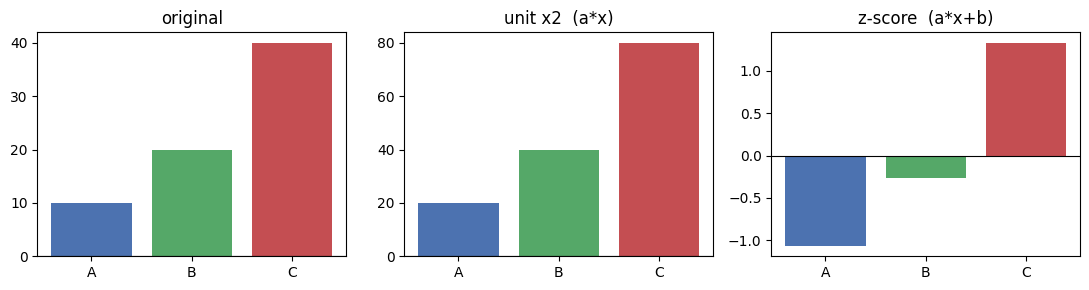

Left two keep A:B:C = 1:2:4.  z-score does not, and 'A' is now negative -> 'twice as much' is gone.


In [13]:
# See it: a*x keeps the proportions; z-score changes them and adds a negative value
fig, ax = plt.subplots(1, 3, figsize=(11,3))
for a_, (t, v) in zip(ax, [("original", x), ("unit x2  (a*x)", 2*x), ("z-score  (a*x+b)", (x-x.mean())/x.std(ddof=0))]):
    a_.bar(["A","B","C"], v, color=["#4C72B0","#55A868","#C44E52"])
    a_.axhline(0, color="k", lw=0.8); a_.set_title(t)
plt.tight_layout(); plt.show()
print("Left two keep A:B:C = 1:2:4.  z-score does not, and 'A' is now negative -> 'twice as much' is gone.")

## Key takeaways

- The **attribute type**, not the storage dtype, decides which statistics are valid.
- **Interval vs ratio** comes down to a **true zero**; test it by changing units and watching the ratio.
- Allowed transforms: **`a·x + b`** for interval, **`a·x`** for ratio — the `+b` is exactly what breaks ratios.